# Modelado de la Curva de Crecimiento de Interacciones — v2

## Cambios respecto a v1

El scraping fue irregular: no todas las publicaciones tienen datos para todos los días.  
El enfoque anterior **interpolaba huecos linealmente y luego promediaba**, lo que introduce dos sesgos:

1. **Sesgo de composición**: el promedio del día N solo incluye publicaciones que fueron capturadas ese día, que tienden a ser las más "longevas" (curvas más lentas).
2. **Interpolación lineal falsa**: rellenar huecos con línea recta introduce curvatura artificial que distorsiona el ajuste del modelo.

### Solución: ajuste directo en datos de panel

En lugar de construir una curva promedio y luego ajustar, ajustamos el modelo **directamente sobre todas las observaciones individuales** `(dia_relativo, fracción)` de todas las publicaciones. Los huecos simplemente no existen — cada observación que sí tenemos aporta información sin necesidad de interpolar nada.

### Modelo usado: Weibull CDF

$$F(t) = 1 - e^{-k \cdot t^{\alpha}}$$

- `k` controla la tasa de crecimiento
- `α` controla la curvatura (si α < 1, el arranque es rápido y luego se desacelera — típico de redes sociales)
- `F(0) = 0` por definición, ancla la curva en cero automáticamente

## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import hashlib
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga y preparación de datos

In [2]:
file_path = 'Scrapping data v2.xlsx'
xl = pd.ExcelFile(file_path)

df_fb = pd.read_excel(xl, sheet_name='Facebook')
df_ig = pd.read_excel(xl, sheet_name='Instagram')
df_tk = pd.read_excel(xl, sheet_name='TikTok')
df_tw = pd.read_excel(xl, sheet_name='Twitter')

def generate_id(text):
    if pd.isna(text): return 'missing_text'
    return hashlib.md5(str(text).encode('utf-8')).hexdigest()

if df_tw['postId'].isnull().all() or df_tw['postId'].astype(str).str.strip().eq('').all():
    df_tw['postId'] = df_tw['text'].apply(generate_id)

def prepare_evolution_df(df, platform, mapping, user_col, id_col, date_pub_col):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()

    actual_user_col = next(
        (col for col in [user_col, 'Username', 'name', 'Candidato'] if col in df.columns), None
    )
    df['candidate'] = df[actual_user_col].astype(str) if actual_user_col else 'Desconocido'
    df = df[~df['candidate'].str.contains('Desconocido|nan|None', case=False, na=True)]

    df['platform'] = platform
    df['internal_post_id'] = platform + '_' + df[id_col].astype(str)
    df = df.rename(columns=mapping)

    p_col = 'fecha_pub' if 'fecha_pub' in df.columns else (date_pub_col if date_pub_col in df.columns else None)
    df['fecha_ext'] = pd.to_datetime(df['fecha_ext'], errors='coerce', dayfirst=True).dt.tz_localize(None)
    df['fecha_pub'] = pd.to_datetime(df[p_col], errors='coerce', dayfirst=True).dt.tz_localize(None)
    df['dia_relativo'] = (df['fecha_ext'] - df['fecha_pub']).dt.days
    # dia_relativo = 0 es el mismo día de publicación
    # Descartamos negativos (errores de fecha) y día 0 si no tiene sentido
    df = df[df['dia_relativo'] >= 0]

    for col in ['likes', 'comments', 'shares']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        else:
            df[col] = 0.0

    return df[['internal_post_id', 'platform', 'candidate', 'fecha_pub', 'dia_relativo',
               'likes', 'comments', 'shares']]

ev_fb = prepare_evolution_df(df_fb, 'Facebook',
    {'megusta': 'likes', 'comentarios': 'comments', 'compartidas': 'shares'},
    'Username', 'postId', 'fecha_pub')
ev_ig = prepare_evolution_df(df_ig, 'Instagram',
    {'megusta': 'likes', 'comentarios': 'comments'},
    'Username', 'postId', 'fecha_pub')
ev_tk = prepare_evolution_df(df_tk, 'TikTok',
    {'megusta': 'likes', 'comentarios': 'comments', 'compartidos': 'shares'},
    'Username', 'postId', 'fecha_pub')
ev_tw = prepare_evolution_df(df_tw, 'Twitter',
    {'likecount': 'likes', 'replycount': 'comments', 'retweet_count': 'shares'},
    'Username', 'postId', 'createdat')

df_combined = pd.concat([ev_fb, ev_ig, ev_tk, ev_tw], ignore_index=True)
df_combined['total_int'] = df_combined['likes'] + df_combined['comments'] + df_combined['shares']

print(f'Publicaciones únicas: {df_combined["internal_post_id"].nunique():,}')
print(f'Observaciones totales: {len(df_combined):,}')
print(f'Plataformas: {df_combined["platform"].value_counts().to_dict()}')
print(f'Días relativos — min: {df_combined["dia_relativo"].min()}, max: {df_combined["dia_relativo"].max()}')

Publicaciones únicas: 2,026
Observaciones totales: 19,439
Plataformas: {'Facebook': 6750, 'Instagram': 5938, 'TikTok': 3943, 'Twitter': 2808}
Días relativos — min: 0, max: 18


## 2. Diagnóstico de la cobertura del scraping

Antes de ajustar cualquier modelo, visualizamos cuántas observaciones tiene cada publicación y en qué días — esto nos ayuda a entender la irregularidad real.

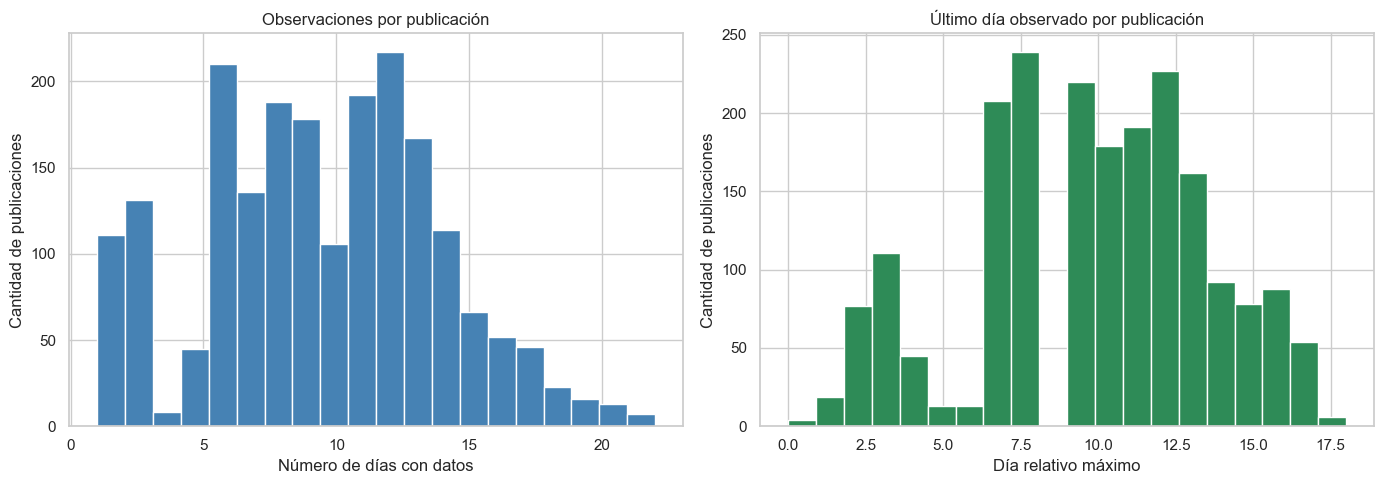

Publicaciones con solo 1 observación: 25
Publicaciones con 2+ observaciones: 2001
Mediana de observaciones por publicación: 10
Mediana del último día observado: 10


In [3]:
# Distribución de observaciones por publicación
obs_per_post = df_combined.groupby('internal_post_id')['dia_relativo'].count()
max_day_per_post = df_combined.groupby('internal_post_id')['dia_relativo'].max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(obs_per_post, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Observaciones por publicación')
axes[0].set_xlabel('Número de días con datos')
axes[0].set_ylabel('Cantidad de publicaciones')

axes[1].hist(max_day_per_post, bins=20, color='seagreen', edgecolor='white')
axes[1].set_title('Último día observado por publicación')
axes[1].set_xlabel('Día relativo máximo')
axes[1].set_ylabel('Cantidad de publicaciones')

plt.tight_layout()
plt.show()

print(f'Publicaciones con solo 1 observación: {(obs_per_post == 1).sum()}')
print(f'Publicaciones con 2+ observaciones: {(obs_per_post >= 2).sum()}')
print(f'Mediana de observaciones por publicación: {obs_per_post.median():.0f}')
print(f'Mediana del último día observado: {max_day_per_post.median():.0f}')

## 3. Construcción del panel de fracciones

**Idea central**: para cada publicación, normalizamos sus interacciones por el **máximo observado más tardío** disponible. Esto nos da la fracción acumulada `F(t) ∈ [0, 1]` en cada día disponible, sin necesidad de interpolar huecos.

**Filtro de calidad**: solo incluimos publicaciones con al menos 2 observaciones (necesitamos al menos dos puntos para aportar información sobre la forma de la curva) y cuya medición más tardía sea al menos el día 3 (para que el denominador sea más confiable).

In [4]:
MIN_OBSERVACIONES = 2   # mínimo de días con datos por publicación
MIN_DIA_MAX = 3         # la observación más tardía debe ser al menos este día

def build_fraction_panel(group):
    """
    Para una publicación, calcula la fracción acumulada en cada día observado.
    Denominador = el valor de total_int en el día más tardío disponible.
    Fuerza monotonicidad (cummax) antes de normalizar.
    """
    group = group.sort_values('dia_relativo').drop_duplicates('dia_relativo')

    # Filtros de calidad
    if len(group) < MIN_OBSERVACIONES:
        return None
    if group['dia_relativo'].max() < MIN_DIA_MAX:
        return None

    # Forzar monotonicidad (scraping puede reportar caídas por caches)
    group = group.copy()
    group['total_int'] = group['total_int'].cummax()

    # Denominador: valor en la observación más tardía
    total_max = group.loc[group['dia_relativo'].idxmax(), 'total_int']

    if total_max <= 0:
        return None

    group['fraccion'] = group['total_int'] / total_max
    group['fraccion'] = group['fraccion'].clip(0, 1)

    return group[['internal_post_id', 'platform', 'candidate',
                  'fecha_pub', 'dia_relativo', 'total_int', 'fraccion']]

panel_list = [
    build_fraction_panel(g)
    for _, g in df_combined.groupby('internal_post_id')
]
df_panel = pd.concat([p for p in panel_list if p is not None], ignore_index=True)

print(f'Publicaciones en el panel: {df_panel["internal_post_id"].nunique():,}')
print(f'Pares (día, fracción) disponibles: {len(df_panel):,}')
print()
print('Por plataforma:')
print(df_panel.groupby('platform')['internal_post_id'].nunique())

Publicaciones en el panel: 1,922
Pares (día, fracción) disponibles: 14,596

Por plataforma:
platform
Facebook     765
Instagram    603
TikTok       344
Twitter      210
Name: internal_post_id, dtype: int64


## 4. Visualización exploratoria del panel

Graficamos todas las trayectorias individuales (semitransparentes) junto con la mediana empírica por día. Esto nos muestra la dispersión real antes de ajustar el modelo.

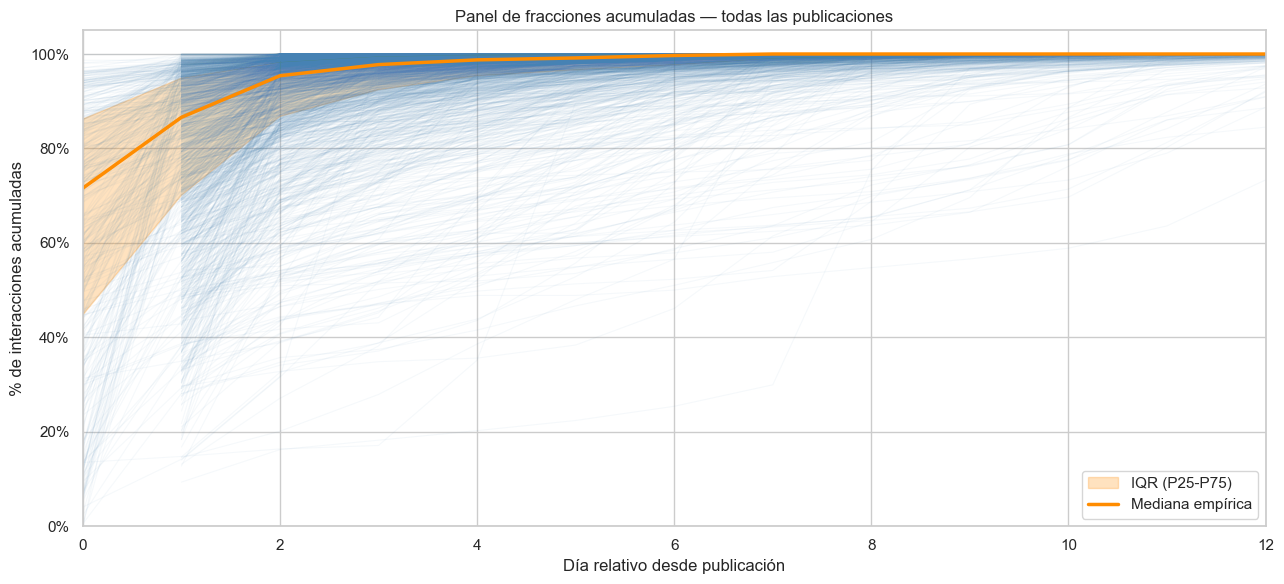

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))

# Trayectorias individuales
for post_id, group in df_panel.groupby('internal_post_id'):
    group = group.sort_values('dia_relativo')
    ax.plot(group['dia_relativo'], group['fraccion'],
            alpha=0.05, color='steelblue', linewidth=0.8)

# Mediana empírica por día (sin interpolación — solo días con datos reales)
empirical = df_panel.groupby('dia_relativo')['fraccion'].agg(['median', 'quantile']).reset_index()
median_curve = df_panel.groupby('dia_relativo')['fraccion'].median().reset_index()
q25 = df_panel.groupby('dia_relativo')['fraccion'].quantile(0.25).reset_index()
q75 = df_panel.groupby('dia_relativo')['fraccion'].quantile(0.75).reset_index()

ax.fill_between(q25['dia_relativo'], q25['fraccion'], q75['fraccion'],
                alpha=0.25, color='darkorange', label='IQR (P25-P75)')
ax.plot(median_curve['dia_relativo'], median_curve['fraccion'],
        color='darkorange', linewidth=2.5, label='Mediana empírica')

ax.set_xlim(0, df_panel['dia_relativo'].quantile(0.95))
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Panel de fracciones acumuladas — todas las publicaciones')
ax.set_xlabel('Día relativo desde publicación')
ax.set_ylabel('% de interacciones acumuladas')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Ajuste del modelo Weibull sobre el panel completo

Ajustamos `F(t) = 1 - exp(-k · t^α)` usando **todos los pares (día, fracción)** del panel como puntos de datos independientes. Esto es equivalente a un ajuste por mínimos cuadrados no lineales ponderado por la cantidad de observaciones disponibles en cada región temporal.

También ajustamos modelos alternativos para comparar.

In [6]:
# Datos del panel para el ajuste
# Excluimos dia_relativo == 0 porque F(0)=0 por definición y puede causar
# inestabilidad numérica en la Weibull cuando alpha < 1
panel_fit = df_panel[df_panel['dia_relativo'] > 0].copy()
x_all = panel_fit['dia_relativo'].values.astype(float)
y_all = panel_fit['fraccion'].values.astype(float)

print(f'Pares usados para el ajuste: {len(x_all):,}')
print(f'Rango de días: {x_all.min():.0f} – {x_all.max():.0f}')
print()

# --- Definición de modelos ---

def weibull_cdf(t, k, alpha):
    """F(t) = 1 - exp(-k * t^alpha). Ancla en F(0)=0."""
    return 1 - np.exp(-k * np.power(t, alpha))

def gompertz(t, a, b, c):
    """F(t) = a * exp(-b * exp(-c*t))"""
    return a * np.exp(-b * np.exp(-c * t))

def logistica(t, L, k, t0):
    """Logística clásica"""
    return L / (1 + np.exp(-k * (t - t0)))

models = [
    ('Weibull CDF',   weibull_cdf, [[0.5, 0.5], [0.1, 0.8], [1.0, 0.4]],   (0, np.inf)),
    ('Gompertz',      gompertz,    [[1, 2, 0.3], [1, 5, 0.5], [1, 1, 0.1]], (0, np.inf)),
    ('Logística',     logistica,   [[1, 0.5, 3], [1, 1, 5], [1, 0.2, 2]],   (0, np.inf)),
]

results = {}

for name, func, p0_list, bounds in models:
    best_r2, best_popt, best_pred = -np.inf, None, None
    for p0 in p0_list:
        try:
            popt, _ = curve_fit(func, x_all, y_all, p0=p0,
                                maxfev=50000, bounds=bounds)
            y_pred = func(x_all, *popt)
            r2 = r2_score(y_all, y_pred)
            if r2 > best_r2:
                best_r2, best_popt, best_pred = r2, popt, y_pred
        except Exception:
            continue
    if best_popt is not None:
        rmse = np.sqrt(mean_squared_error(y_all, best_pred))
        results[name] = {'func': func, 'params': best_popt, 'r2': best_r2, 'rmse': rmse}
        print(f'{name:20s} | R²: {best_r2:.4f} | RMSE: {rmse:.4f} | Params: {np.round(best_popt, 4)}')
    else:
        print(f'{name:20s} | No convergió')

best_name = max(results, key=lambda n: results[n]['r2'])
best_func   = results[best_name]['func']
best_params = results[best_name]['params']
print(f'\n→ Mejor modelo: {best_name} (R² = {results[best_name]["r2"]:.4f})')

Pares usados para el ajuste: 14,226
Rango de días: 1 – 18

Weibull CDF          | R²: 0.2554 | RMSE: 0.0988 | Params: [1.6215 0.4607]
Gompertz             | R²: 0.2519 | RMSE: 0.0990 | Params: [0.9863 0.3928 0.656 ]
Logística            | R²: 0.1584 | RMSE: 0.1051 | Params: [1.7411 0.0297 0.    ]

→ Mejor modelo: Weibull CDF (R² = 0.2554)


## 6. Visualización del ajuste

Comparamos los modelos ajustados contra la mediana empírica del panel.

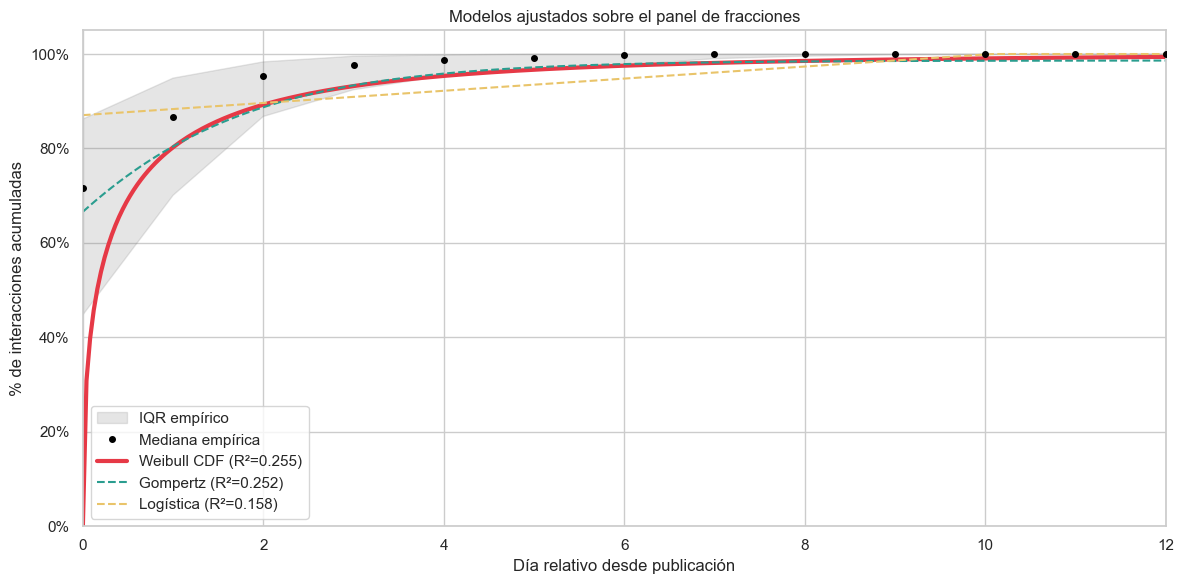

In [7]:
t_plot = np.linspace(0, df_panel['dia_relativo'].quantile(0.95), 300)

fig, ax = plt.subplots(figsize=(12, 6))

# Banda IQR empírica
ax.fill_between(q25['dia_relativo'], q25['fraccion'], q75['fraccion'],
                alpha=0.2, color='gray', label='IQR empírico')
ax.plot(median_curve['dia_relativo'], median_curve['fraccion'],
        'o', color='black', markersize=4, label='Mediana empírica', zorder=5)

colors = ['#E63946', '#2A9D8F', '#E9C46A']
for (name, res), color in zip(results.items(), colors):
    y_curve = res['func'](t_plot, *res['params'])
    y_curve = np.clip(y_curve, 0, 1)
    lw = 3 if name == best_name else 1.5
    ls = '-' if name == best_name else '--'
    ax.plot(t_plot, y_curve, color=color, linewidth=lw, linestyle=ls,
            label=f'{name} (R²={res["r2"]:.3f})')

ax.set_xlim(0, t_plot.max())
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Modelos ajustados sobre el panel de fracciones')
ax.set_xlabel('Día relativo desde publicación')
ax.set_ylabel('% de interacciones acumuladas')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Análisis de residuos

Revisamos si los errores del mejor modelo tienen algún patrón sistemático por día relativo o por plataforma. Un patrón sistemático indicaría que el modelo no captura bien alguna región de la curva.

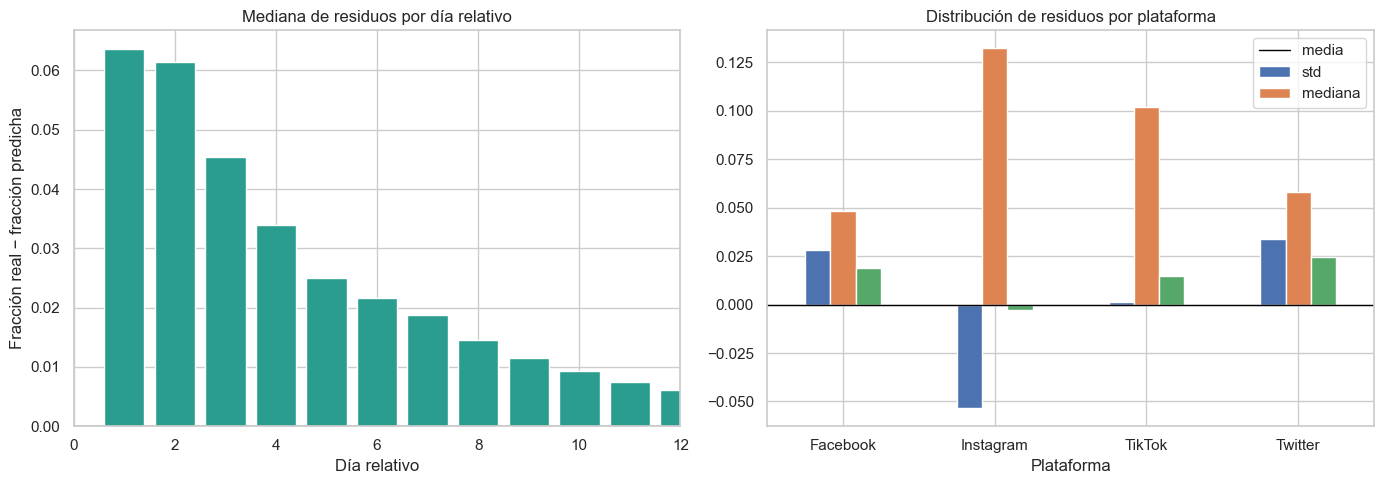

¿Hay sesgo sistemático por plataforma?
platform
Facebook     0.0281
Instagram   -0.0535
TikTok       0.0012
Twitter      0.0336
Name: residuo, dtype: float64


In [8]:
panel_fit = panel_fit.copy()
panel_fit['y_pred'] = best_func(panel_fit['dia_relativo'].values.astype(float), *best_params)
panel_fit['residuo'] = panel_fit['fraccion'] - panel_fit['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuos por día relativo
res_by_day = panel_fit.groupby('dia_relativo')['residuo'].median()
axes[0].bar(res_by_day.index, res_by_day.values, color=[
    '#E63946' if v < 0 else '#2A9D8F' for v in res_by_day.values
], width=0.8)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlim(0, df_panel['dia_relativo'].quantile(0.95))
axes[0].set_title('Mediana de residuos por día relativo')
axes[0].set_xlabel('Día relativo')
axes[0].set_ylabel('Fracción real − fracción predicha')

# Residuos por plataforma
res_by_platform = panel_fit.groupby('platform')['residuo'].describe()[['mean', 'std', '50%']]
res_by_platform.plot(kind='bar', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Distribución de residuos por plataforma')
axes[1].set_xlabel('Plataforma')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['media', 'std', 'mediana'])

plt.tight_layout()
plt.show()

print('¿Hay sesgo sistemático por plataforma?')
print(panel_fit.groupby('platform')['residuo'].mean().round(4))

## 8. (Opcional) Modelos por plataforma

Si el análisis de residuos anterior muestra sesgos distintos por plataforma, conviene ajustar un modelo separado para cada una. Esta celda hace ese ajuste automáticamente.

Facebook     | k=2.2668, α=0.4217 | R²=0.3500
Instagram    | k=1.1561, α=0.5139 | R²=0.3356
TikTok       | k=1.7708, α=0.3746 | R²=0.1930
Twitter      | k=1.8758, α=0.9675 | R²=0.4069


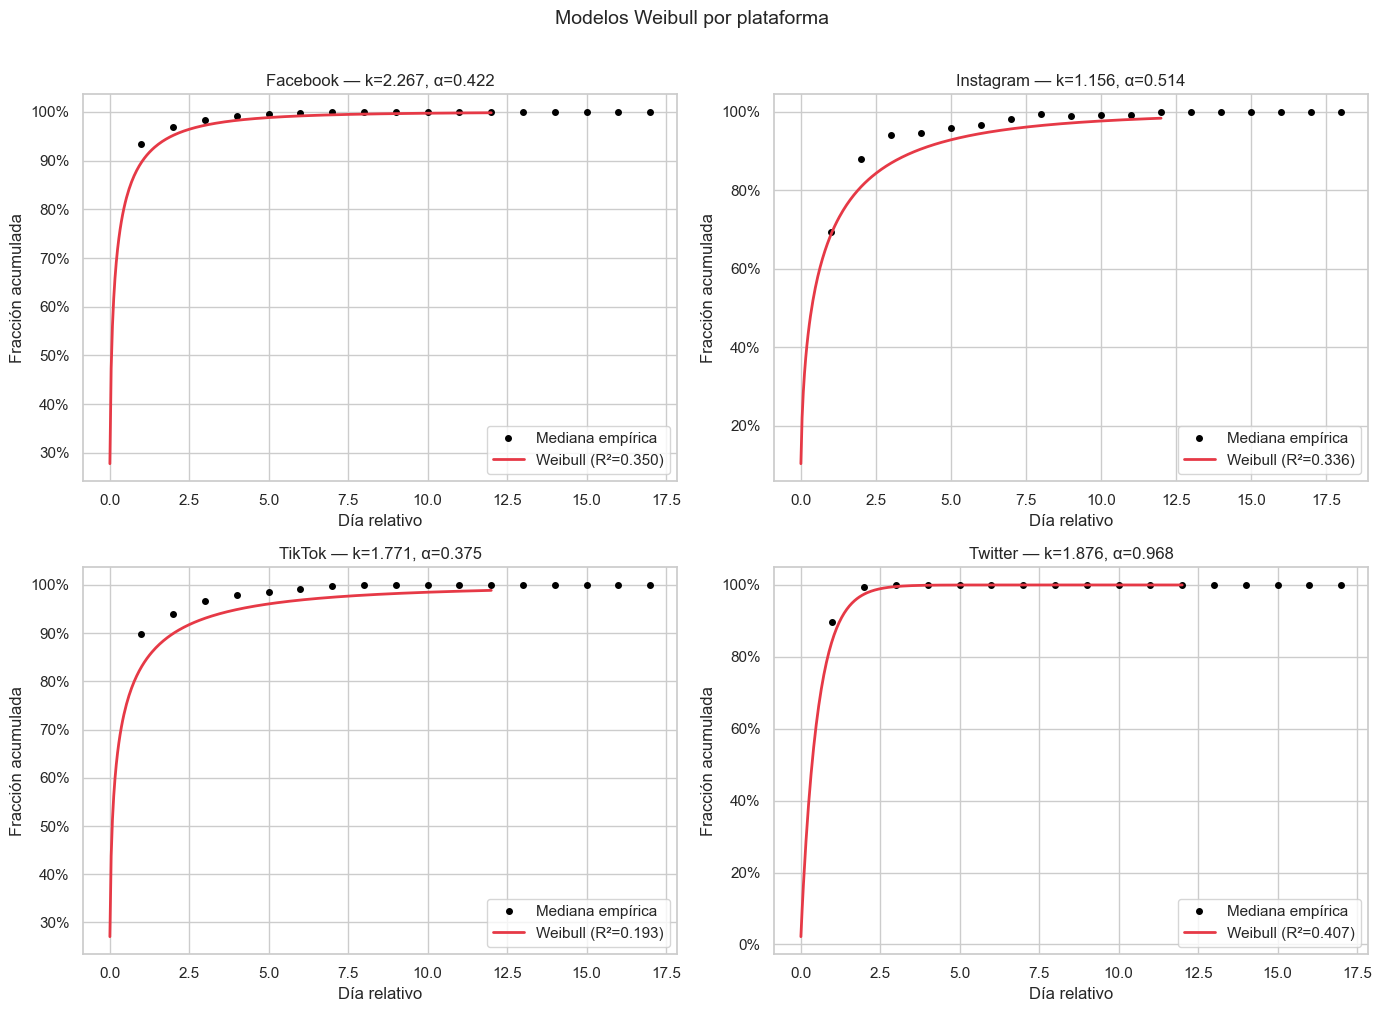

In [9]:
platform_models = {}

t_plot = np.linspace(0.01, df_panel['dia_relativo'].quantile(0.95), 300)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, platform in enumerate(df_panel['platform'].unique()):
    sub = df_panel[(df_panel['platform'] == platform) & (df_panel['dia_relativo'] > 0)]
    if len(sub) < 10:
        print(f'{platform}: datos insuficientes')
        continue

    x_p = sub['dia_relativo'].values.astype(float)
    y_p = sub['fraccion'].values.astype(float)

    best_r2_p, best_popt_p = -np.inf, None
    for p0 in [[0.5, 0.5], [0.1, 0.8], [1.0, 0.4]]:
        try:
            popt, _ = curve_fit(weibull_cdf, x_p, y_p, p0=p0,
                                maxfev=50000, bounds=(0, np.inf))
            r2 = r2_score(y_p, weibull_cdf(x_p, *popt))
            if r2 > best_r2_p:
                best_r2_p, best_popt_p = r2, popt
        except Exception:
            continue

    if best_popt_p is not None:
        platform_models[platform] = {'params': best_popt_p, 'r2': best_r2_p}

        med_p = sub.groupby('dia_relativo')['fraccion'].median()
        axes[i].plot(med_p.index, med_p.values, 'o', color='black', markersize=4,
                     label='Mediana empírica')
        y_curve = np.clip(weibull_cdf(t_plot, *best_popt_p), 0, 1)
        axes[i].plot(t_plot, y_curve, color='#E63946', linewidth=2,
                     label=f'Weibull (R²={best_r2_p:.3f})')
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        axes[i].set_title(f'{platform} — k={best_popt_p[0]:.3f}, α={best_popt_p[1]:.3f}')
        axes[i].set_xlabel('Día relativo')
        axes[i].set_ylabel('Fracción acumulada')
        axes[i].legend()
        print(f'{platform:12s} | k={best_popt_p[0]:.4f}, α={best_popt_p[1]:.4f} | R²={best_r2_p:.4f}')

plt.suptitle('Modelos Weibull por plataforma', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Función de reconstrucción histórica

Esta es la función principal: dado una fecha de publicación y el total de interacciones conocido (medido en cualquier momento posterior), reconstruye la curva diaria estimada.

**Lógica**:
- Si se provee `total_interacciones` y `fecha_observacion`, el modelo primero estima cuál es el porcentaje que ese total representa (usando el modelo para saber en qué punto de la curva estamos), y de ahí infiere el total final teórico.
- Si se provee directamente `total_final`, lo usa como denominador sin escalar.

In [10]:
def reconstruir_curva(
    fecha_pub,
    total_interacciones,
    fecha_observacion=None,
    platform=None,
    dias_reconstruir=20,
    global_func=best_func,
    global_params=best_params,
    platform_models=platform_models
):
    """
    Reconstruye la curva histórica de interacciones de una publicación.

    Parámetros
    ----------
    fecha_pub : str o datetime
        Fecha de publicación del post.
    total_interacciones : int o float
        Número de interacciones conocidas. Si se provee fecha_observacion,
        se interpreta como el total en ese momento (parcial) y se escala
        para estimar el total final. Si no se provee, se trata como total final.
    fecha_observacion : str o datetime, opcional
        Fecha en que se midió total_interacciones. Si es None, se asume
        que total_interacciones es el total final ya estabilizado.
    platform : str, opcional
        Plataforma ('Facebook', 'Instagram', 'TikTok', 'Twitter').
        Si se provee y existe un modelo por plataforma, lo usa.
    dias_reconstruir : int
        Número de días a reconstruir desde la fecha de publicación.

    Retorna
    -------
    pd.DataFrame con columnas: Fecha, Día Relativo, % Acumulado,
                                Interacciones Estimadas, Interacciones Nuevas
    """
    fecha_pub = pd.to_datetime(fecha_pub)

    # Seleccionar modelo (por plataforma si existe, si no el global)
    func = global_func
    params = global_params
    if platform and platform in platform_models:
        func = weibull_cdf
        params = platform_models[platform]['params']

    # Estimar el total final
    if fecha_observacion is not None:
        fecha_obs = pd.to_datetime(fecha_observacion)
        dia_obs = max(1, (fecha_obs - fecha_pub).days)
        fraccion_en_obs = func(float(dia_obs), *params)
        fraccion_en_obs = np.clip(fraccion_en_obs, 0.01, 1.0)  # evitar div/0
        total_final = total_interacciones / fraccion_en_obs
        print(f'Día de observación: {dia_obs} | '
              f'Fracción estimada en ese día: {fraccion_en_obs:.1%} | '
              f'Total final estimado: {total_final:,.0f}')
    else:
        total_final = total_interacciones
        print(f'Total final (dado directamente): {total_final:,.0f}')

    # Construir curva día a día
    dias = np.arange(0, dias_reconstruir + 1)
    fraccion = np.clip(func(np.where(dias == 0, 1e-9, dias.astype(float)), *params), 0, 1)
    fraccion[0] = 0.0  # anclar en cero

    interacciones_cum = np.round(fraccion * total_final).astype(int)
    interacciones_nuevas = np.diff(interacciones_cum, prepend=0)
    fechas = [fecha_pub + pd.Timedelta(days=int(d)) for d in dias]

    return pd.DataFrame({
        'Fecha': fechas,
        'Día Relativo': dias,
        '% Acumulado': fraccion,
        'Interacciones Estimadas': interacciones_cum,
        'Interacciones Nuevas (ese día)': interacciones_nuevas
    })

## 10. Ejemplos de uso

In [11]:
# --- Ejemplo A: conoces el total final directamente ---
print('=== Ejemplo A: total final conocido ===')
curva_a = reconstruir_curva(
    fecha_pub='2026-01-15',
    total_interacciones=50_000,
    dias_reconstruir=20
)
print(curva_a.to_string(index=False))

=== Ejemplo A: total final conocido ===
Total final (dado directamente): 50,000
     Fecha  Día Relativo  % Acumulado  Interacciones Estimadas  Interacciones Nuevas (ese día)
2026-01-15             0     0.000000                        0                               0
2026-01-16             1     0.802406                    40120                           40120
2026-01-17             2     0.892635                    44632                            4512
2026-01-18             3     0.932105                    46605                            1973
2026-01-19             4     0.953623                    47681                            1076
2026-01-20             5     0.966741                    48337                             656
2026-01-21             6     0.975317                    48766                             429
2026-01-22             7     0.981203                    49060                             294
2026-01-23             8     0.985392                    49270   

In [12]:
# --- Ejemplo B: tienes una medición parcial en un día específico ---
print('=== Ejemplo B: medición parcial + fecha de observación ===')
curva_b = reconstruir_curva(
    fecha_pub='2026-01-15',
    total_interacciones=43_000,     # lo que tenía el día 10
    fecha_observacion='2026-01-25', # día en que se midió
    platform='Instagram',
    dias_reconstruir=20
)
print(curva_b.to_string(index=False))

=== Ejemplo B: medición parcial + fecha de observación ===
Día de observación: 10 | Fracción estimada en ese día: 97.7% | Total final estimado: 44,010
     Fecha  Día Relativo  % Acumulado  Interacciones Estimadas  Interacciones Nuevas (ese día)
2026-01-15             0     0.000000                        0                               0
2026-01-16             1     0.685298                    30160                           30160
2026-01-17             2     0.808109                    35565                            5405
2026-01-18             3     0.869092                    38248                            2683
2026-01-19             4     0.905316                    39843                            1595
2026-01-20             5     0.928897                    40880                            1037
2026-01-21             6     0.945157                    41596                             716
2026-01-22             7     0.956831                    42110                           

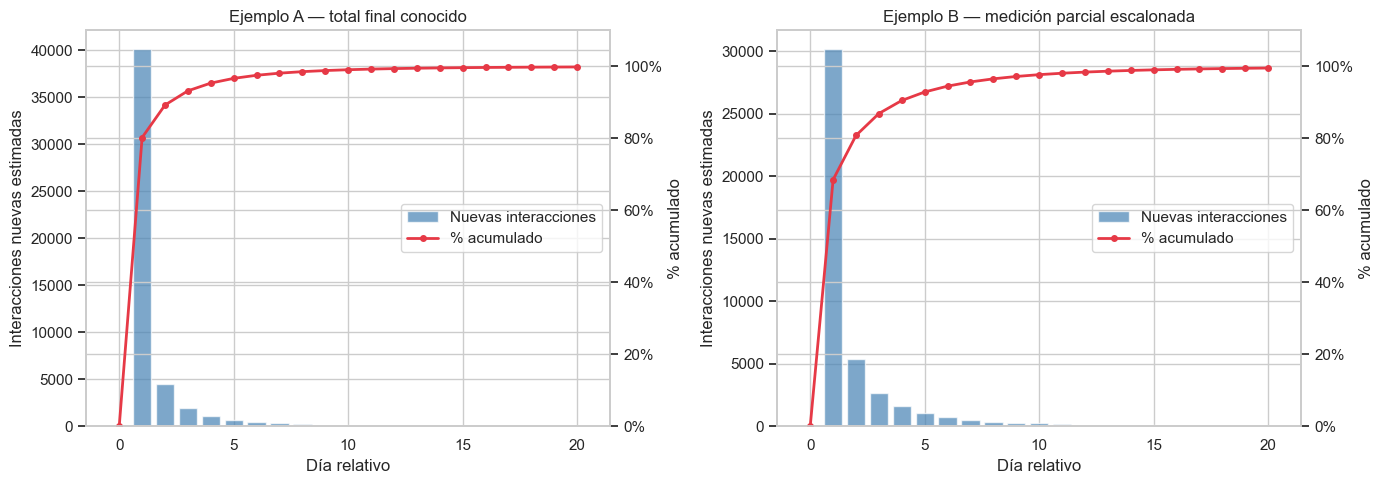

In [13]:
# --- Visualización de la reconstrucción ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (curva, titulo) in zip(axes, [
    (curva_a, 'Ejemplo A — total final conocido'),
    (curva_b, 'Ejemplo B — medición parcial escalonada')
]):
    ax.bar(curva['Día Relativo'], curva['Interacciones Nuevas (ese día)'],
           color='steelblue', alpha=0.7, label='Nuevas interacciones')
    ax2 = ax.twinx()
    ax2.plot(curva['Día Relativo'], curva['% Acumulado'],
             color='#E63946', linewidth=2, marker='o', markersize=4,
             label='% acumulado')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax2.set_ylim(0, 1.1)
    ax.set_title(titulo)
    ax.set_xlabel('Día relativo')
    ax.set_ylabel('Interacciones nuevas estimadas')
    ax2.set_ylabel('% acumulado')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()